# Lecture 7 - Monte Carlo sampling 

## Introduction and theory
In this notebook describes the results obtained using a Monte Carlo sampling algorithm applied to the sampling of the (N,V,T) canonical ensemble starting from different configurations in order to try to simulate gaseous, solid and liquid states of matter. 

### Canonical ensemble
In the canonical ensemble the total energy $E$ is not conserved, while the temperature $T$ is. To fix the temperature $T$, we will suppose that we put the system, we are interested in, with $N$ particles in a volume $V$ and Hamiltonian $H(q,p)$ in contact with a much larger system, which we will call reservoir (or heat bath) characterized by $N_b\gg N$, $V_b\gg V$ and the Hamiltonian $H_b(q_b,p_b)$. System and bath can freely exchange energy. Once the equilibrium is reached,they will have the same temperature; but since the bath is much larger than the system, we can assume that its temperature $T$ does not vary.

The probability density given the energy $E=H(q,p)$ reads
$$
\rho (q,p) = \dfrac{1}{Q_N(V,T)} e^{-H(q,p)/k_B T}
$$
The normalization (i.e. the volume in the phase space occupied by the canonical ensemble) is given by
$$
Q_N(V,T) = \displaystyle \int \dfrac{1}{h^{3N}N!}e^{-H(q,p)/k_BT}\ d^{3N}q d^{3N}p
$$

### Importance sampling with M(RT)$^2$
Standard Metropolis algorithms often use random displacements that don't know anything about the target distribution $p(x)$, leading to high rejection rates. This method incorporates prior knowledge of the distribution into the proposal step.

If the target distribution can be factorized as $p(x) = d_1(x) \cdot d_2(x)$, and we can easily sample from $d_1(x)$, we can use $d_1(x)$ as our trial transition probability
$$
T(x|y) = d_1(x)
$$
When we plug this specific $T(x|y)$ into the standard Metropolis acceptance formula, the $d_1$ terms cancel out, simplifying the calculation
$$
A(x|y) = \min \left[ 1, \frac{T(y|x) \cdot p(x)}{T(x|y) \cdot p(y)} \right] = \min \left[ 1, \frac{d_1(y) \cdot d_1(x)d_2(x)}{d_1(x) \cdot d_1(y)d_2(y)} \right] = \min \left[ 1, \frac{d_2(x)}{d_2(y)} \right]
$$
If $p(x) = d_1(x)$ (meaning $d_2 = 1$), the acceptance $A(x|y)$ is always $1$. By making $T(x|y)$ more close to $p(x)$, we can increase the average acceptance rate.

Re-weighting allows us to estimate a whole series of integrals depending on a parameter $a$ without having to run a new Monte Carlo simulation for every single value of $a$. The goal is to compute a series of integrals $I_a$ for different values of $a$
$$
I_a = \int_{\Omega} d\vec{x} \ g(\vec{x}) \frac{p_a(\vec{x})}{\int d\vec{x} \ p_a(\vec{x})}
$$

### Exercise 07.1
In the `NSL simulator` code we have provided, include tail corrections for potential energy, $U$, and pressure $P$.

### Theory and solution - 07.1
In this section we are improving the provided `NSL simulator` code by including some tail corrections for potential energy $U$ and pressure $P$.

In numerical simulations frequently use a potential with a spherical cutoff at a distance $r_c$ and it becomes useful to correct the results of these to compensate for the missing long-range part of the potential. The additional contributions for distances $r > r_c$ are estimated by assuming that the radial distribution function is approximately 1 in these regions, so it represents a uncorrelated system.

The tail corrections follow these equations
$$
\dfrac{\langle V_{LJ}\rangle_\text{tail}}{N} \approx \dfrac{8\pi \rho_{LJ}\varepsilon}{3r_{c,LJ}^3} \left(\dfrac{1}{3r_{c,LJ}^6 } - 1\right)
$$
$$
\dfrac{\langle w_{LJ}\rangle_\text{tail}}{3N\varepsilon} \approx 32 \pi \rho_{LJ} \left(\dfrac{1}{9r_{c,LJ}^9 } - \dfrac{1}{6r_{c,LJ}^3 }\right)
$$
and are implemented in `_vtail_` and `_ptail_`.

### Exercise 07.2
Use the NSL simulator code to print out **instantaneous** values of potential energy per particle, $U/N$, along **equilibrated** Monte Carlo $(N,V,T)$ and Molecular Dynamics $(N,V,E)$ simulations of $M=5\times 10^5$ MC steps or MD time steps (where, for MC, the Metropolis acceptance ratio should be fixed approximately to 50% by changing the value of $dt$ that, in the MC case, represent the amplitude of the step in each direction) in the following thermodynamic conditions:
- liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r^\star_c = 2.5$, for MD $dt^\star=0.001$)

Equilibration is needed both with MC and with MD. With MD, you will observe that starting from a perfect crystalline configuration the temperature, $T$, will not conserve its value. Explore and find the starting value of $T$ needed to stabilize, after a certain number of time steps (equilibration time), the average value of $T$ on the desired $T^\star$.
Perform your MC and MD simulations by re-starting after such equilibration time.

1. Once this data has been produced, compute and make pictures with a python script of the autocorrelation functions of $U/N$ to approximately estimate how large the blocks in your simulations should be.
2. Use the same data to study, with a python script, the estimation of the statistical uncertainties of the expectation value of $U/N$ for different size of the blocks in the data blocking technique, from $L=M/N=10$ to $L=5\times 10^3$, being $N$ the number of blocks. Make pictures of these statistical uncertainties as a function of $L$. What you observe in the statistical uncertainties after that the block size is large enough (from the point of view of the data blocking technique)?

### Implementation and theory - 07.2
The goal of this part is to thermalize the system, for both MD and MC, in a liquid phase characterized by $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r^\star_c = 2.5$, for MD $dt^\star=0.001$).

Before performing simulations, it is always necessary to bring the system into a state of equilibrium both in MD and MC simulations. This is achieved when the average probability of finding our system in a state μ is proportional to the Boltzmann weight p(μ) of that state. In practical terms we monitore the trend of a quantity of interest as a function of the steps.

1. MD simulation $\rightarrow$ our starting positions are dictated by a FCC configuration that occupies the entire simulation box. In this specific case, attempting to start from an FCC configuration that occupies only half the box (as seen in Lesson 4) does not allow the system to reach equilibrium. This is due to the high intensity of forces in the initial configuration. To allow the system to equilibrate at a target temperature of $T^* = 1.1$, we start with a temperature $T_{start} = 1.98$. From the plot below  less than ($\sim 2000$) are required to thermalize our system.

2. MC simulation $\rightarrow$ the starting configuration is again a FCC. In MC simulations conversely to MD simulations the right temperature is set immediately, because we are not following a physical model that calculates quantities at each move, the temperature in the Metropolis algorithm appears only in the acceptance probability. 
Particular attention must be paid to the choice of the step size $dt$, as we want to maintain an acceptance ratio $ \sim 50%$. It is observed that optimal acceptance values are obtained when $dt = 0.1$.

In the next cell some plots of the $10^4$ blocks (of $1$ step each) equilibration are reported, specifically the potential energy for both MC and MD, and the temperature for the MD.

In [30]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib import cm
import math
viridis = plt.cm.viridis
color_MD = viridis(0.2)
color_MC = viridis(0.6)
plt.style.use('default')
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

In [49]:
def plot_thermalization(
    pot_file_MD,
    pot_file_MC,
    temp_file,
    T_ref,
    color_MD=color_MD,
    color_MC=color_MC
):

    data_pot_MD = np.loadtxt(pot_file_MD, skiprows=1)
    blocks_pot_MD, pot_MD = data_pot_MD[:, 0], data_pot_MD[:, 1]

    data_pot_MC = np.loadtxt(pot_file_MC, skiprows=1)
    blocks_pot_MC, pot_MC = data_pot_MC[:, 0], data_pot_MC[:, 1]

    data_temp = np.loadtxt(temp_file, skiprows=1)
    blocks_temp, temp = data_temp[:, 0], data_temp[:, 1]

    fig = plt.figure(figsize=(20, 6), dpi=100)

    ax0 = fig.add_subplot(1, 3, 1)
    ax1 = fig.add_subplot(1, 3, 2, sharey=ax0)
    ax2 = fig.add_subplot(1, 3, 3)

    ax0.plot(blocks_pot_MC, pot_MC, '-', color=color_MC, linewidth=0.8)
    ax0.set_xlabel('Block', fontsize=12)
    ax0.set_ylabel('Potential energy - MC simulation', fontsize=12)
    ax0.grid(True, alpha=0.6, linestyle='--')

    ax1.plot(blocks_pot_MD, pot_MD, '-', color=color_MD, linewidth=0.8)
    ax1.set_xlabel('Block', fontsize=12)
    ax1.set_ylabel('Potential energy - MD simulation', fontsize=12)
    ax1.grid(True, alpha=0.6, linestyle='--')

    ax2.plot(blocks_temp, temp, '-', color=color_MD, linewidth=0.8)
    ax2.axhline(
        y=T_ref,
        color='red',
        linewidth=0.8,
        linestyle='-.',
        label=rf'Thermalization T$^* = {T_ref}$'
    )
    ax2.set_xlabel('Block', fontsize=12)
    ax2.set_ylabel('Temperature - MD simulation', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.6, linestyle='--')

    plt.tight_layout()
    plt.show()
    
def plot_MD_vs_MC(file_MD, file_MC, ylabel_energy='Potential energy [eV]', ylabel_error='Statistical error [eV]'):

    x_MD, E_MD, err_MD = np.loadtxt(file_MD, usecols=(0, 2, 3), unpack=True, comments='#')
    x_MC, E_MC, err_MC = np.loadtxt(file_MC, usecols=(0, 2, 3), unpack=True, comments='#')
    
    fig, axs = plt.subplots(1, 2, figsize=(14, 6), dpi=100, sharex=True)
    
    
    axs[0].plot(x_MD, E_MD, 'o-', color=color_MD, alpha=0.7, markersize=5,label='MD')
    axs[0].fill_between(x_MD, E_MD-err_MD, E_MD+err_MD,
                       color=color_MD, alpha=0.25)
    axs[0].plot(x_MC, E_MC, 'o-', color=color_MC, alpha=0.7, markersize=5,label='MC')
    axs[0].fill_between(x_MC, E_MC-err_MC, E_MC+err_MC,
                       color=color_MC, alpha=0.25)
    axs[0].set_xlabel('Blocks', fontsize=12)
    axs[0].set_ylabel(ylabel_energy, fontsize=12)
    axs[0].legend(fontsize=12)
    axs[0].grid(True, alpha=0.6, linestyle='--')
    
    axs[1].plot(
        x_MD, err_MD,
        '-', color=color_MD, alpha=0.8, label='MD'
    )
    axs[1].plot(
        x_MC, err_MC,
        '-', color=color_MC, alpha=0.8, label='MC'
    )
    axs[1].set_xlabel('Blocks', fontsize=12)
    axs[1].set_ylabel(ylabel_error, fontsize=12)
    axs[1].legend(fontsize=12)
    axs[1].grid(True, alpha=0.6, linestyle='--')
    
    plt.tight_layout()
    plt.show()


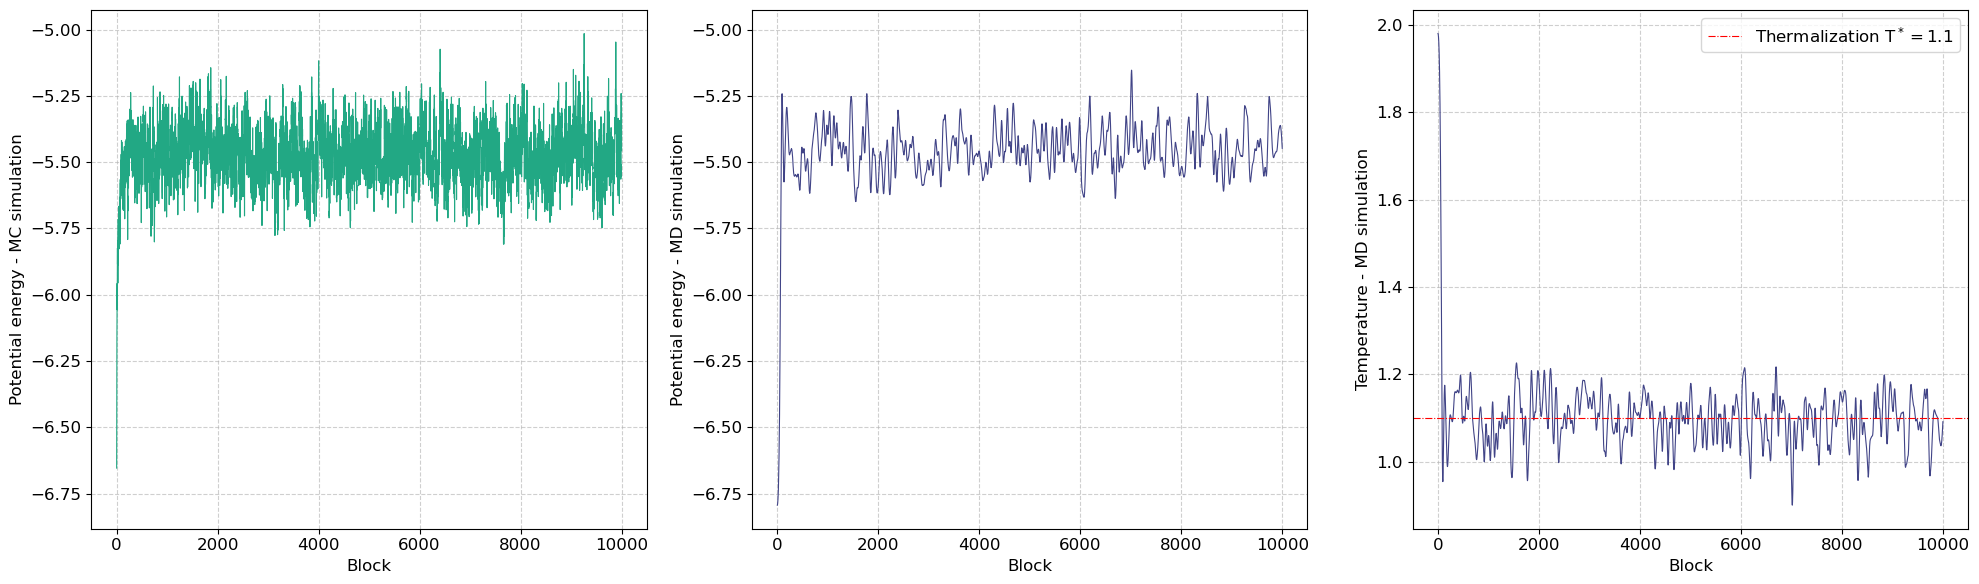

In [50]:
plot_thermalization(
    pot_file_MD='MD_CODE/OUTPUT/THERMALIZATION/potential_energy.dat',
    pot_file_MC='MC_CODE/OUTPUT/THERMALIZATION/potential_energy.dat',
    temp_file='MD_CODE/OUTPUT/THERMALIZATION/temperature.dat',
    T_ref=1.1
)

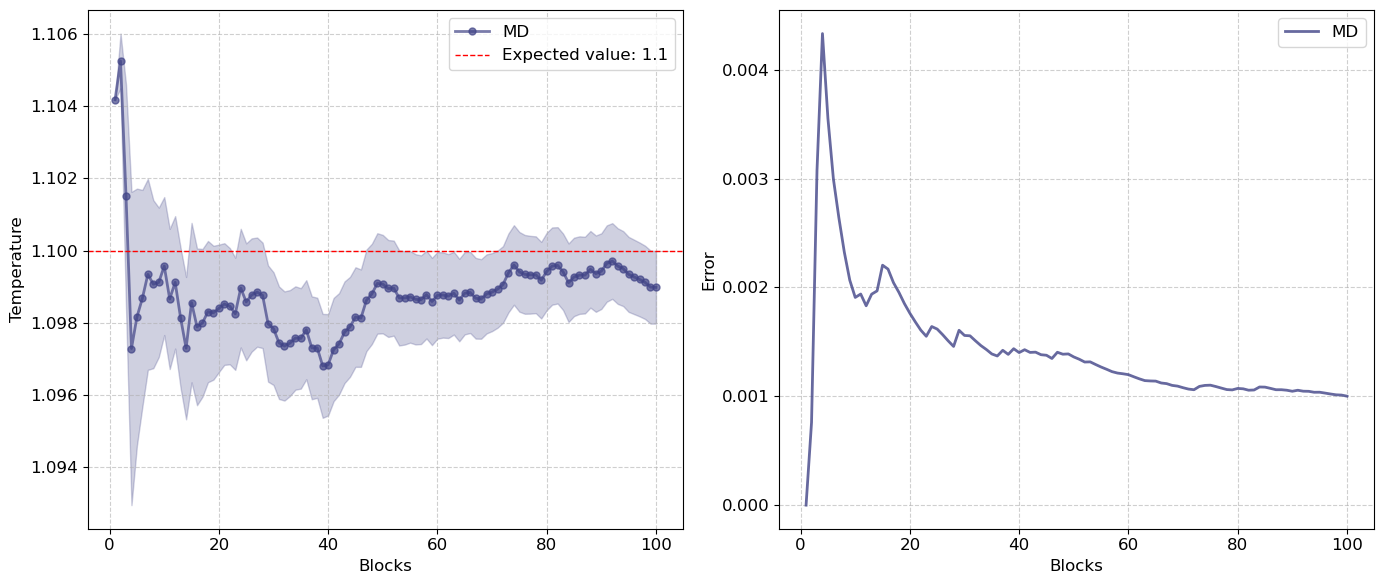

In [ ]:
file_MD= "MD_CODE/OUTPUT/FIRST/temperature.dat"
x_MD, E_MD, err_MD = np.loadtxt(file_MD, usecols=(0, 2, 3), unpack=True, comments='#')

fig, axs = plt.subplots(1, 2, figsize=(14, 6), dpi=100, sharex=True)
    
    
axs[0].plot(x_MD, E_MD, 'o-', color=color_MD, alpha=0.7, markersize=5,label='MD')
axs[0].fill_between(x_MD, E_MD-err_MD, E_MD+err_MD,
                       color=color_MD, alpha=0.25)
axs[0].set_xlabel('Blocks', fontsize=12)
axs[0].set_ylabel('Temperature', fontsize=12)
axs[0].axhline(y=1.1, color='r', linestyle='--', linewidth=1,
                 label=f'Expected value: {1.1:.1f}')
axs[0].legend(fontsize=12)
axs[0].grid(True, alpha=0.6, linestyle='--')
    
axs[1].plot(
        x_MD, err_MD,
        '-', color=color_MD, alpha=0.8, label='MD'
    )
axs[1].set_xlabel('Blocks', fontsize=12)
axs[1].set_ylabel('Error', fontsize=12)
axs[1].legend(fontsize=12)
axs[1].grid(True, alpha=0.6, linestyle='--')
    
plt.tight_layout()
plt.show()

### Autocorrelation functions
In the study of complex systems, memory refers to the capacity of past events to influence future dynamics. This influence often manifests as scale-invariant behavior over time. To quantify this, we use autocorrelation, which represents the statistical covariance between a stationary random process $x$ and a time-shifted version of itself.Autocorrelation is a fundamental tool for identifying the presence of memory and measuring the degree of statistical dependence within a process.

To effectively analyze a simulation, we must determine the correlation time ($t_c$). This value defines the time required for a system to transition from its current state to a new state that is statistically independent. This is estimated using the time-dependent autocorrelation function $\chi(t)$:
$$
\chi(t) = \frac{\langle m(t')m(t' + t) \rangle_{t'} - \langle m \rangle^2}{\sigma_m^2}
$$
The behavior of $\chi(t)$ categorizes the system's memory:
| Condition | Resulting dynamics|
| :--- | :---: |
| $\chi(t) = 0, \forall t > 0$ | No memory, observations are immediately independent. |
| $\chi(t) = 0, \forall t > t_c$ | Finite memory, he process becomes independent after time $t_c$. |
| $\chi(t) \approx t^{-a}$ ($a > 0, t \gg 0$) | Long-range memory, persistent dependence across all time scales (power-law). |

For large time scales, we generally expect autocorrelation to decay exponentially: $\chi(t) \approx e^{-t/t_c}$. To ensure that the samples collected from a simulation are truly independent, it is standard practice to take measurements at intervals of $\ge 2t_c$.If a simulation runs for a total duration $t_{max}$ (following an initial equilibration period $t_{eq}$), the number of statistically independent measurements $n$ is calculated as:$$n = \frac{t_{max}}{2t_c}$$

In discrete-time systems like Markov Chains, the autocorrelation formula is expressed as:$$\chi(t) = \frac{\frac{1}{t_{max}-t} \sum_{t'=0}^{t_{max}-t} m(t')m(t' + t) - \left(\frac{1}{t_{max}-t} \sum_{t'=0}^{t_{max}-t} m(t')\right) \left(\frac{1}{t_{max}-t} \sum_{t'=0}^{t_{max}-t} m(t' + t)\right)}{\frac{1}{t_{max}} \sum_{t'=0}^{t_{max}} m^2(t') - \left( \frac{1}{t_{max}} \sum_{t'=0}^{t_{max}} m(t') \right)^2}$$

In practice we used $M=5\cdot10^5$ blocks of 1 step each, so a simulation of $5\cdot10^5$ steps, in order to compute the autocorrelation functions and to estimate a suitable length of each block for our simulations, which has been estimated at $L=2000$ steps per block.

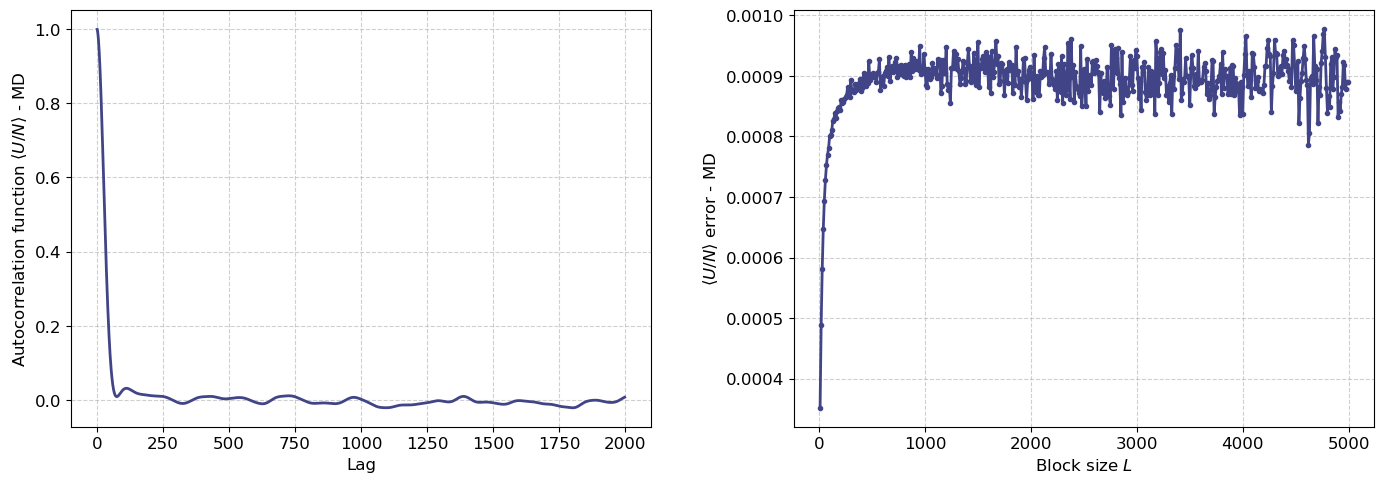

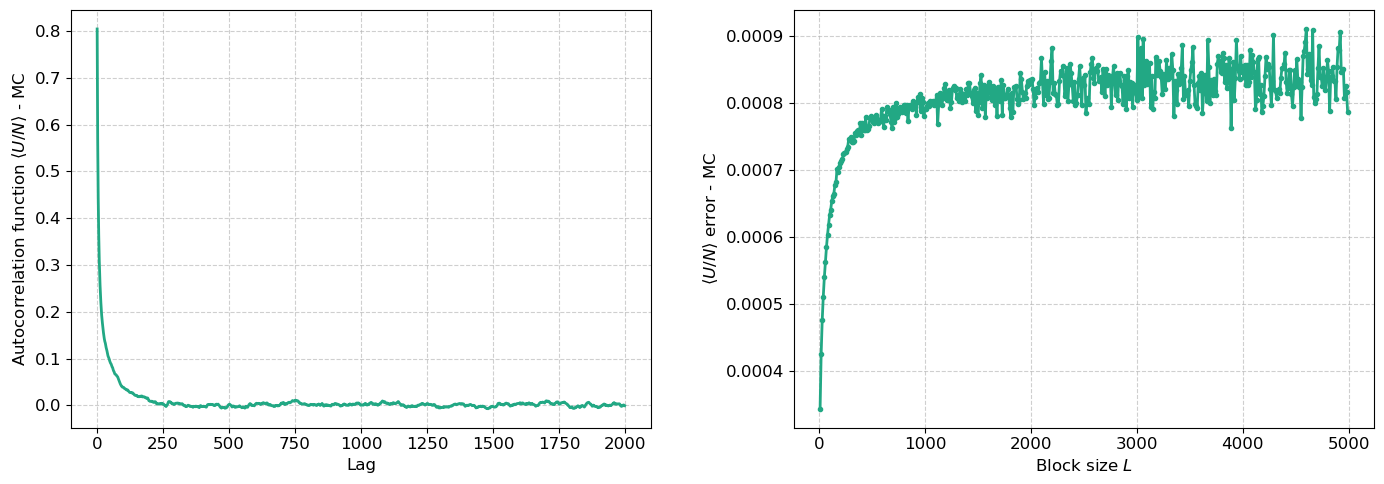

In [33]:
n_throws = 500000
max_lag = 2000
sizes = [10 * i for i in range(1, 500)] 
def autocorr(data, t):
    N = len(data)
    mean = np.mean(data)
    var = np.var(data)
    if var == 0:
        return 0
    sum_prod = np.sum((data[:N - t] - mean) * (data[t:] - mean))
    return sum_prod / ((N - t) * var)

def error(AV, AV2, n):
    if n == 0:
        return 0
    return math.sqrt((AV2[n] - AV[n]**2) / n)

def blockerror(data, N, L):
    ave = np.array([np.mean(data[i*L:(i+1)*L]) for i in range(N)])
    av2 = ave**2
    sum_prog = np.cumsum(ave) / np.arange(1, N+1)
    sum2_prog = np.cumsum(av2) / np.arange(1, N+1)
    return error(sum_prog, sum2_prog, N-1)
file_path_md = "MD_CODE/OUTPUT/CORRELATION/potential_energy.dat"
data_md = np.loadtxt(file_path_md, usecols=1, max_rows=n_throws, skiprows=1)

auto_md = [autocorr(data_md, t) for t in range(1, max_lag)]

valid_sizes_md = [L for L in sizes if n_throws // L >= 2]
errors_md = [blockerror(data_md, n_throws // L, L) for L in valid_sizes_md]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, max_lag), auto_md, color=color_MD)
axes[0].set_xlabel("Lag", fontsize=12)
axes[0].set_ylabel("Autocorrelation function $\\langle U/N \\rangle$ - MD",  fontsize=12)
axes[0].grid(True, alpha=0.6, linestyle='--')

axes[1].plot(valid_sizes_md, errors_md, marker='.', color=color_MD)
axes[1].set_xlabel("Block size $L$", fontsize=12)
axes[1].set_ylabel("$\\langle U/N \\rangle$ error - MD", fontsize=12)
axes[1].grid(True, alpha=0.6, linestyle='--')

plt.tight_layout(h_pad=3, w_pad=3)
plt.show()

file_path_mc = "MC_CODE/OUTPUT/CORRELATION/potential_energy.dat"
data_mc = np.loadtxt(file_path_mc, usecols=1, max_rows=n_throws, skiprows=1)

auto_mc = [autocorr(data_mc, t) for t in range(1, max_lag)]

valid_sizes_mc = [L for L in sizes if n_throws // L >= 2]
errors_mc = [blockerror(data_mc, n_throws // L, L) for L in valid_sizes_mc]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, max_lag), auto_mc, color=color_MC)
axes[0].set_xlabel("Lag", fontsize=12)
axes[0].set_ylabel("Autocorrelation function $\\langle U/N \\rangle$ - MC",  fontsize=12)
axes[0].grid(True, alpha=0.6, linestyle='--')

axes[1].plot(valid_sizes_mc, errors_mc, marker='.', color=color_MC)
axes[1].set_xlabel("Block size $L$", fontsize=12)
axes[1].set_ylabel("$\\langle U/N \\rangle$ error - MC", fontsize=12)
axes[1].grid(True, alpha=0.6, linestyle='--')

plt.tight_layout(h_pad=3, w_pad=3)
plt.show()

### Exercise 07.3
Include the calculation of the radial distribution function, $g(r)$, as a function of the radial distance $r$ among particles, with $r \in \left[ 0; L/2\right]$ inside the NSL simulator code: average value of $g(r)$ in each block, final average value of $g(r)$ with statistical uncertainties in a separate file.

### Implementation and theory - 07.3


### Exercise 07.4
By means of your upgraded NSL simulator code, equilibrate and perform MC NVT and MD NVE simulations via a Lennard-Jones model of Argon ($\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) in the following conditions:
- liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r_c = 2.5$)

show in pictures the obtained average values and uncertainties for the potential energy per particle, $U/N$, the pressure $P$ and the radial distribution function $g(r)$ in LJ units ...  and compare your MC results for these quantities with those obtained via MD NVE simulations in similar thermodynamic conditions.

In [34]:
def plot_g_r_rmsd(file_md, file_mc, n_bins=100, color_MD=color_MD, color_MC=color_MC):

    data_md = np.loadtxt(file_md)
    data_mc = np.loadtxt(file_mc)

    n_blocks_md = data_md.shape[0] // n_bins
    n_blocks_mc = data_mc.shape[0] // n_bins
    n_blocks = min(n_blocks_md, n_blocks_mc)

    r_md, g_md, err_md = data_md[:, 0], data_md[:, 2], data_md[:, 3]
    r_mc, g_mc, err_mc = data_mc[:, 0], data_mc[:, 2], data_mc[:, 3]

    ymax = max(np.max(g_md + err_md), np.max(g_mc + err_mc))

    rmsd_blocks = []
    for i in range(n_blocks):
        s = i * n_bins
        e = s + n_bins
        diff2 = (g_md[s:e] - g_mc[s:e])**2
        rmsd_blocks.append(np.sqrt(np.mean(diff2)))
    rmsd_blocks = np.array(rmsd_blocks)

    fig, (ax_md, ax_mc, ax_rmsd) = plt.subplots(1, 3, figsize=(18, 6))

    for ax in (ax_md, ax_mc):
        ax.set_xlabel(r"$r$", fontsize=14)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_ylim(0, ymax * 1.1)
        ax.set_ylabel(r"$g(r)$", fontsize=14)

    s = (n_blocks - 1) * n_bins
    e = s + n_bins

    ax_md.errorbar(r_md[s:e], g_md[s:e], yerr=err_md[s:e],
                   fmt='o', ms=4, capsize=2, color=color_MD,
                   alpha=0.85, label="MD simulation")
    ax_mc.errorbar(r_mc[s:e], g_mc[s:e], yerr=err_mc[s:e],
                   fmt='o', ms=4, capsize=2, color=color_MC,
                   alpha=0.85, label="MC simulation")

    ax_md.legend(fontsize=12)
    ax_mc.legend(fontsize=12)

    ax_rmsd.plot(np.arange(1, n_blocks+1), rmsd_blocks, marker='o', color='tab:green')
    ax_rmsd.set_xlabel("Blocks", fontsize=14)
    ax_rmsd.set_ylabel("RMSD MD vs MC", fontsize=14)
    ax_rmsd.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

In [81]:
def plot_MD_vs_MC(file_MD, file_MC, ylabel):
    x_MD, E_MD, err_MD = np.loadtxt(file_MD, usecols=(0, 2, 3), unpack=True, comments='#')
    x_MC, E_MC, err_MC = np.loadtxt(file_MC, usecols=(0, 2, 3), unpack=True, comments='#')

    fig, axs = plt.subplots(1, 2, figsize=(14, 6), dpi=100, sharex=True)
    
    
    axs[0].plot(x_MD, E_MD, 'o-', color=color_MD, alpha=0.7, markersize=5,label='MD')
    axs[0].plot(x_MC, E_MC, 'o-', color=color_MC, alpha=0.7, markersize=5,label='MC')
    axs[0].fill_between(x_MD, E_MD-err_MD, E_MD+err_MD,
                       color=color_MD, alpha=0.25)
    axs[0].fill_between(x_MC, E_MC-err_MC, E_MC+err_MC,
                       color=color_MC, alpha=0.25)
    axs[0].set_xlabel('Blocks', fontsize=12)
    axs[0].set_ylabel(ylabel, fontsize=12)
    axs[0].axhline(y=E_MD[-1], color='r', linestyle='--', linewidth=1,
                 label=rf'MD best value: {E_MD[-1]:.3f}$\pm${err_MD[-1]:.3f}')
    axs[0].axhline(y=E_MC[-1], color='brown', linestyle=':', linewidth=1,
                 label=rf'MC best value: {E_MC[-1]:.3f}$\pm${err_MC[-1]:.3f}')
    axs[0].legend(fontsize=12)
    axs[0].grid(True, alpha=0.6, linestyle='--')
    
    axs[1].plot(x_MD, err_MD,'-', color=color_MD, alpha=0.8, label='MD')
    axs[1].plot(x_MC, err_MC,'-.', color=color_MC, alpha=0.8, label='MC')
    axs[1].set_xlabel('Blocks', fontsize=12)
    axs[1].set_ylabel('Error', fontsize=12)
    axs[1].legend(fontsize=12)
    axs[1].grid(True, alpha=0.6, linestyle='--')
    
    plt.tight_layout()
    plt.show()

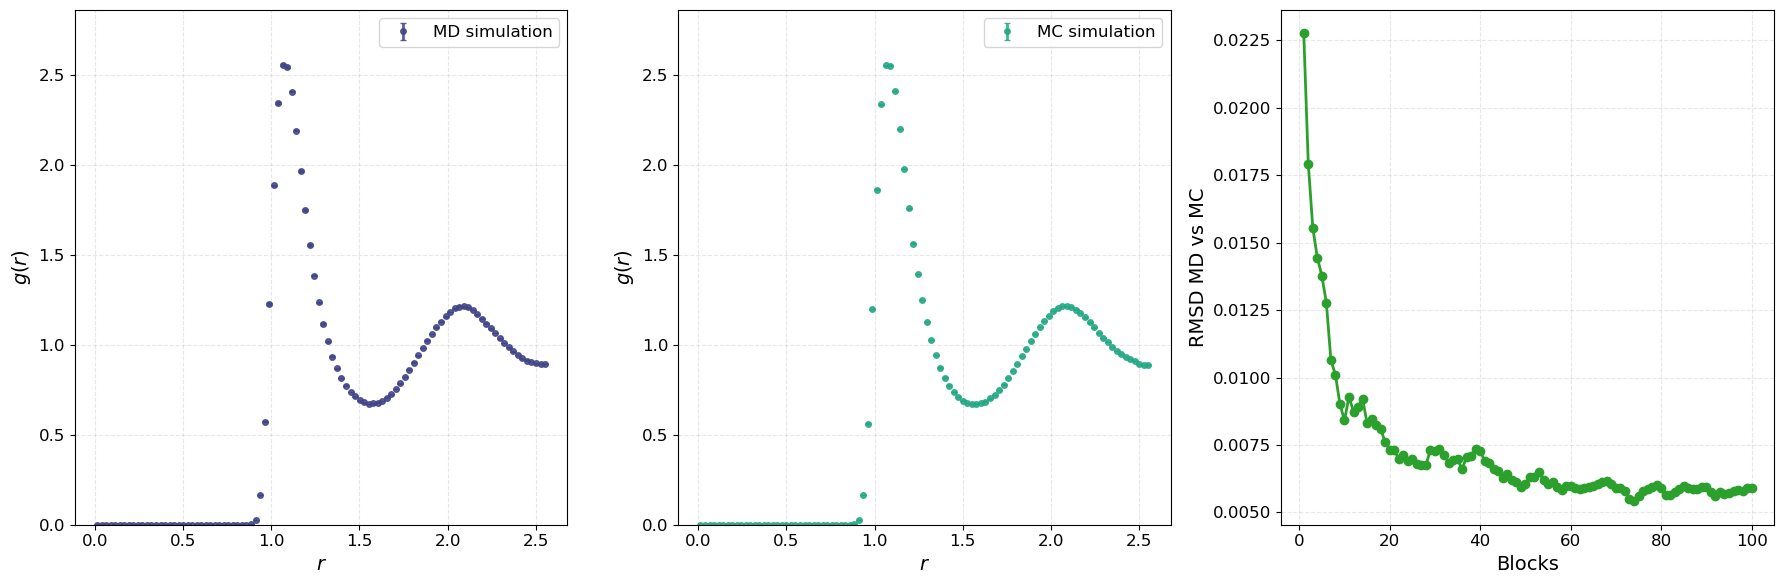

In [82]:
plot_g_r_rmsd(
    "MD_CODE/OUTPUT/FIRST/gofr.dat",
    "MC_CODE/OUTPUT/FIRST/gofr.dat",
    n_bins=100
)

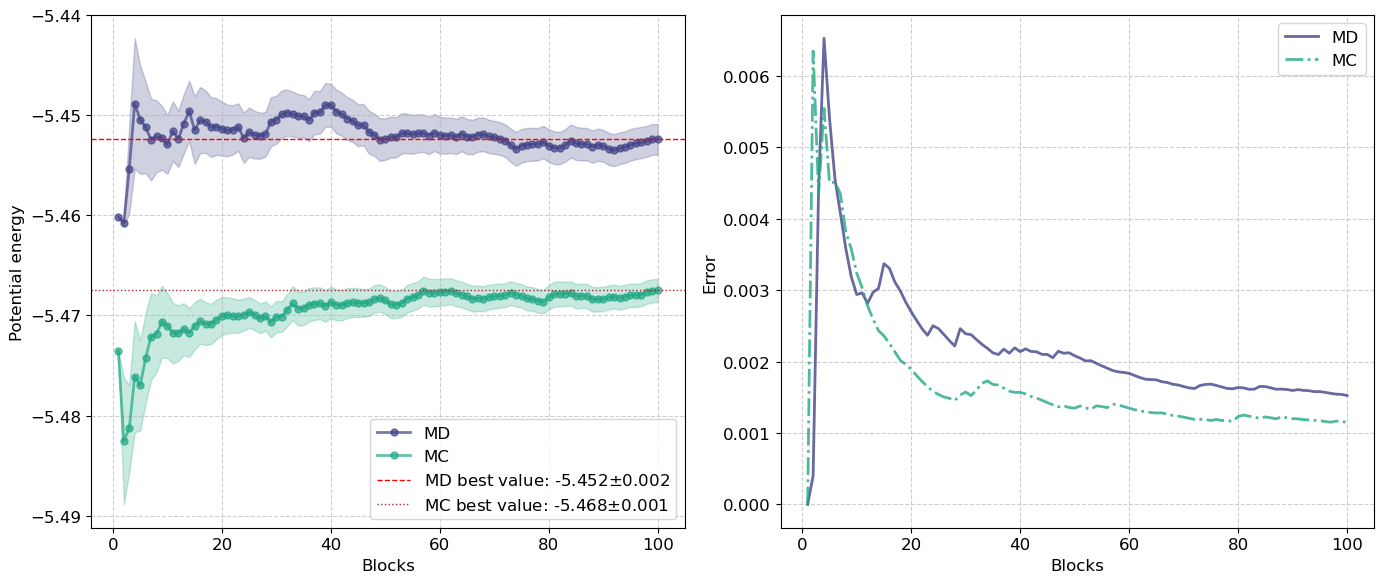

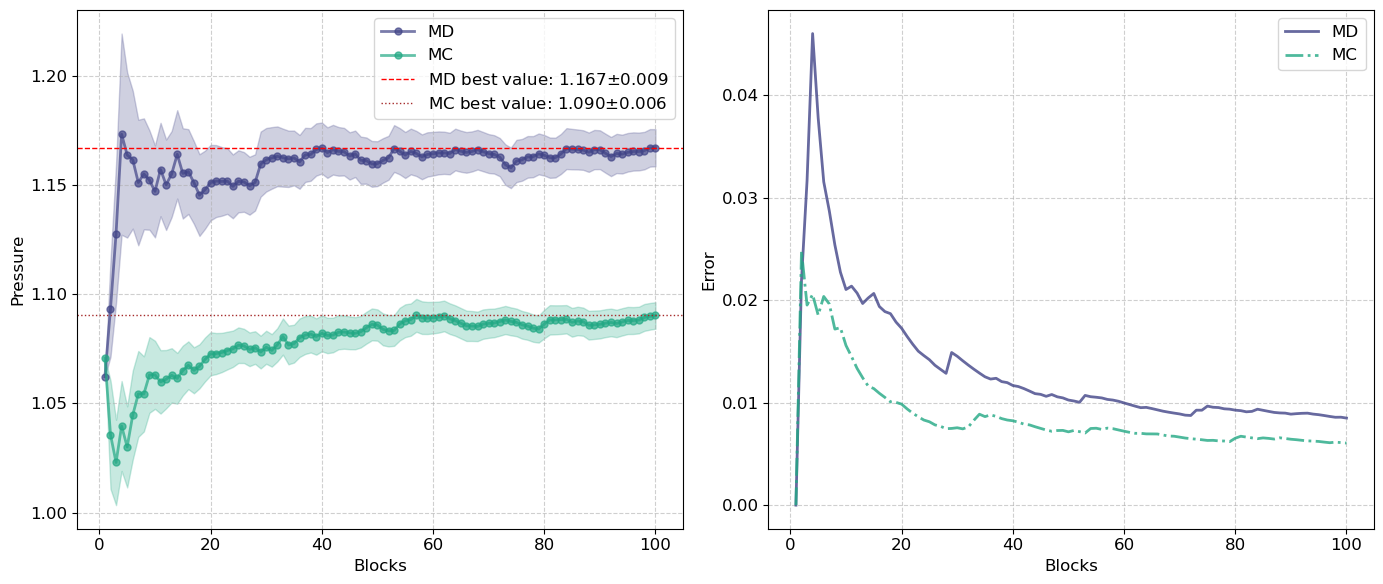

In [83]:
plot_MD_vs_MC("MD_CODE/OUTPUT/FIRST/potential_energy.dat", "MC_CODE/OUTPUT/FIRST/potential_energy.dat",'Potential energy')
plot_MD_vs_MC("MD_CODE/OUTPUT/FIRST/pressure.dat", "MC_CODE/OUTPUT/FIRST/pressure.dat",'Pressure')

### Extra part 
Exercises 7.2 and 7.4 repeated in the following different thermodynamic conditions:
- solid phase: $\rho^\star = 1.1$, $T^\star = 0.8$ (cut-off radius: $r^\star_c = 2.2$)
- gas phase: $\rho^\star = 0.05$, $T^\star = 1.2$ (cut-off radius: $r^\star_c = 5.0$)

### Solid phase

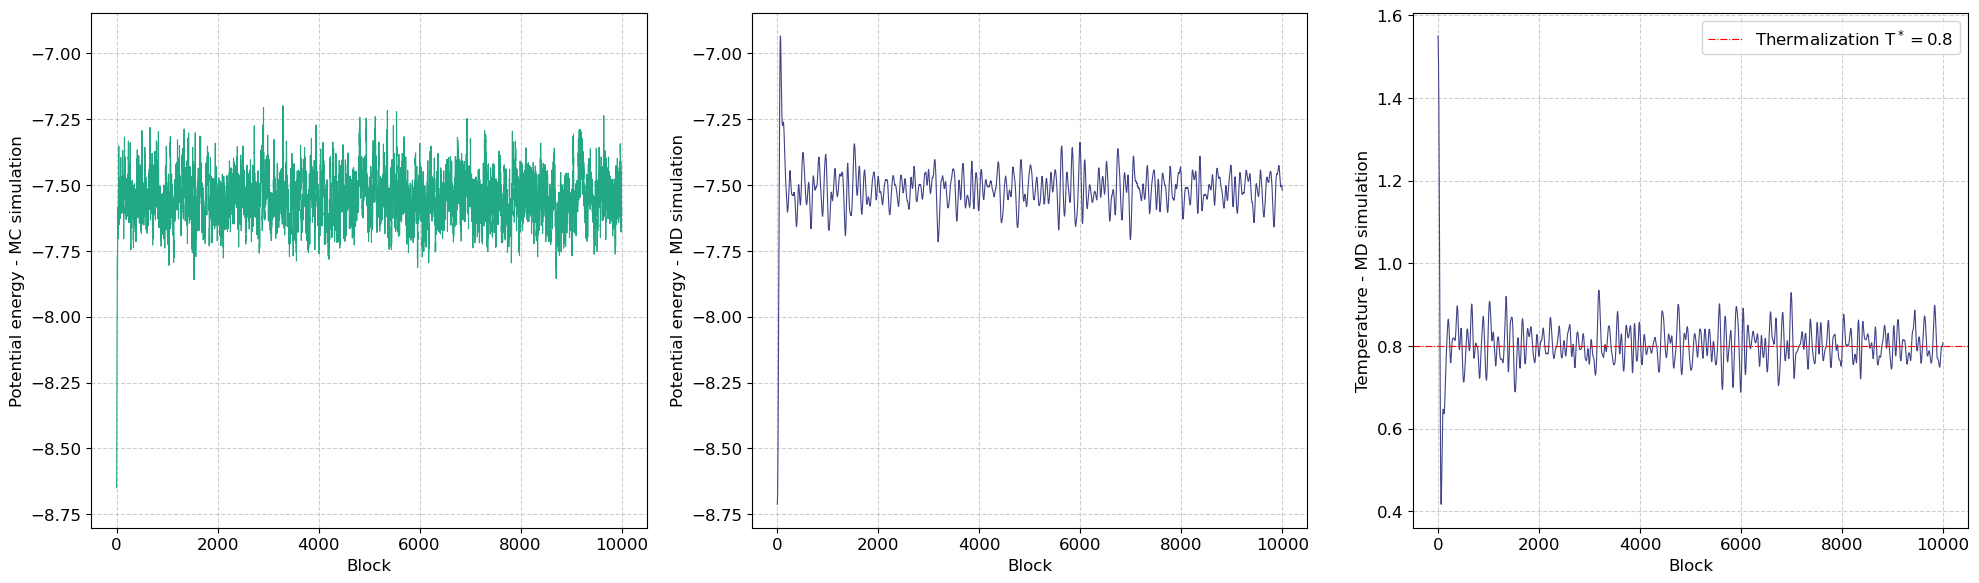

In [38]:
plot_thermalization(
    pot_file_MD='MD_CODE/OUTPUT/SOLID/THERMALIZATION/potential_energy.dat',
    pot_file_MC='MC_CODE/OUTPUT/SOLID/THERMALIZATION/potential_energy.dat',
    temp_file='MD_CODE/OUTPUT/SOLID/THERMALIZATION/temperature.dat',
    T_ref=0.8
)

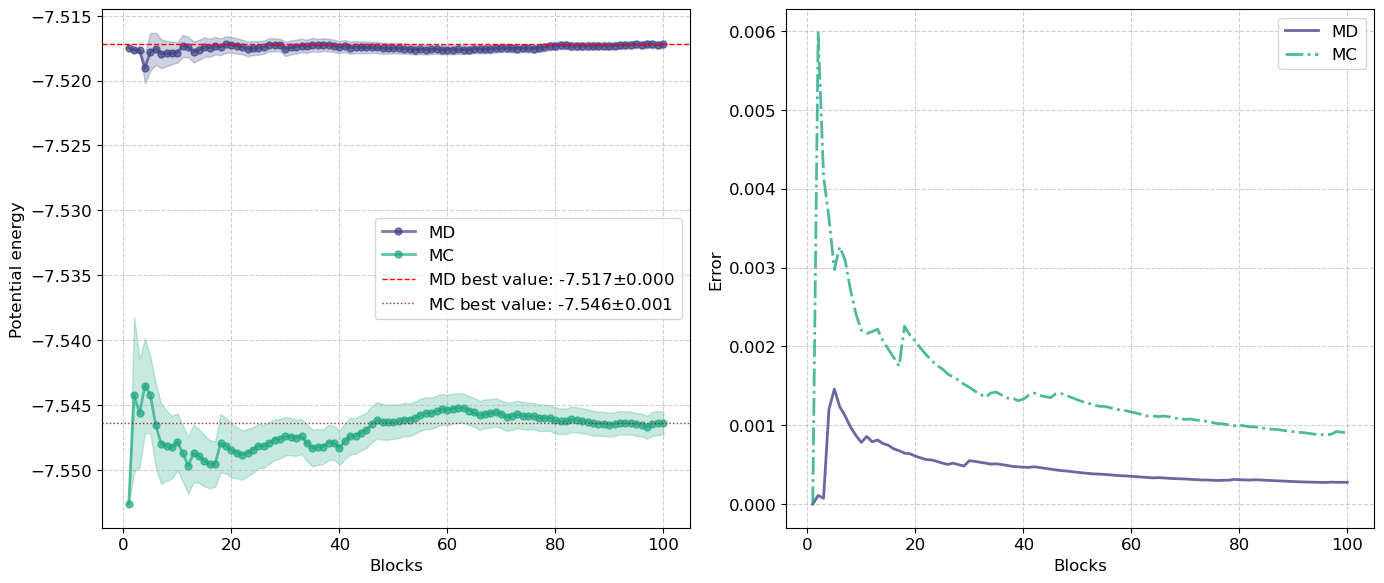

In [84]:
plot_MD_vs_MC("MD_CODE/OUTPUT/SOLID/potential_energy.dat", "MC_CODE/OUTPUT/SOLID/potential_energy.dat",'Potential energy')

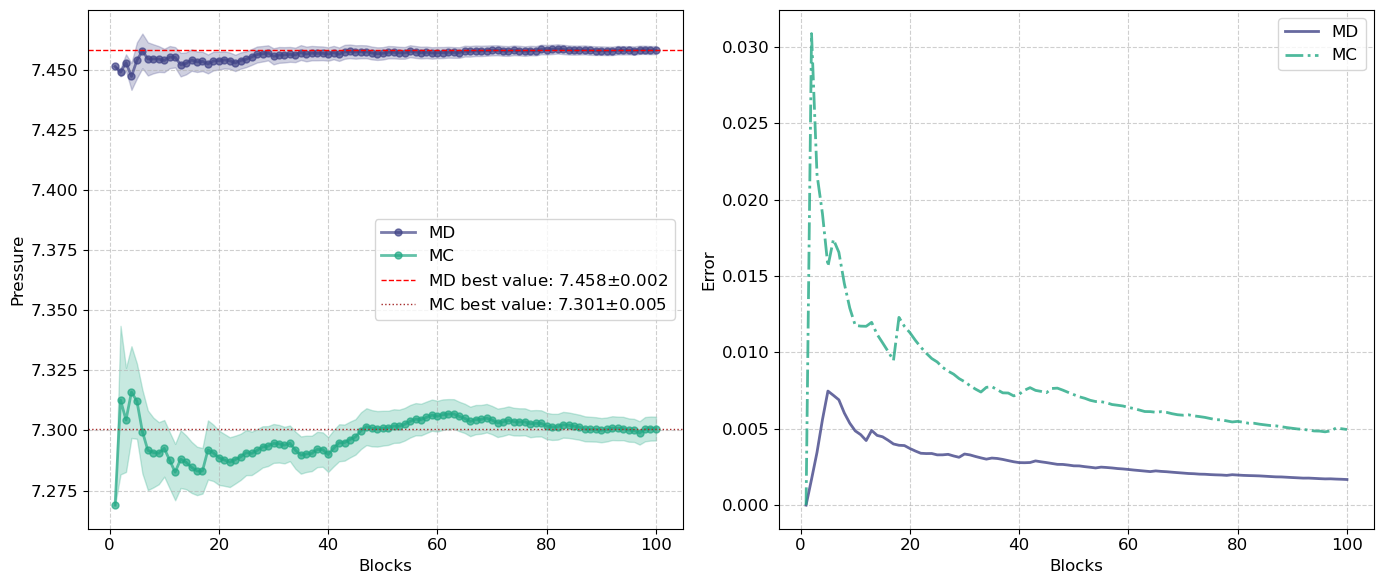

In [85]:
plot_MD_vs_MC("MD_CODE/OUTPUT/SOLID/pressure.dat", "MC_CODE/OUTPUT/SOLID/pressure.dat",'Pressure')

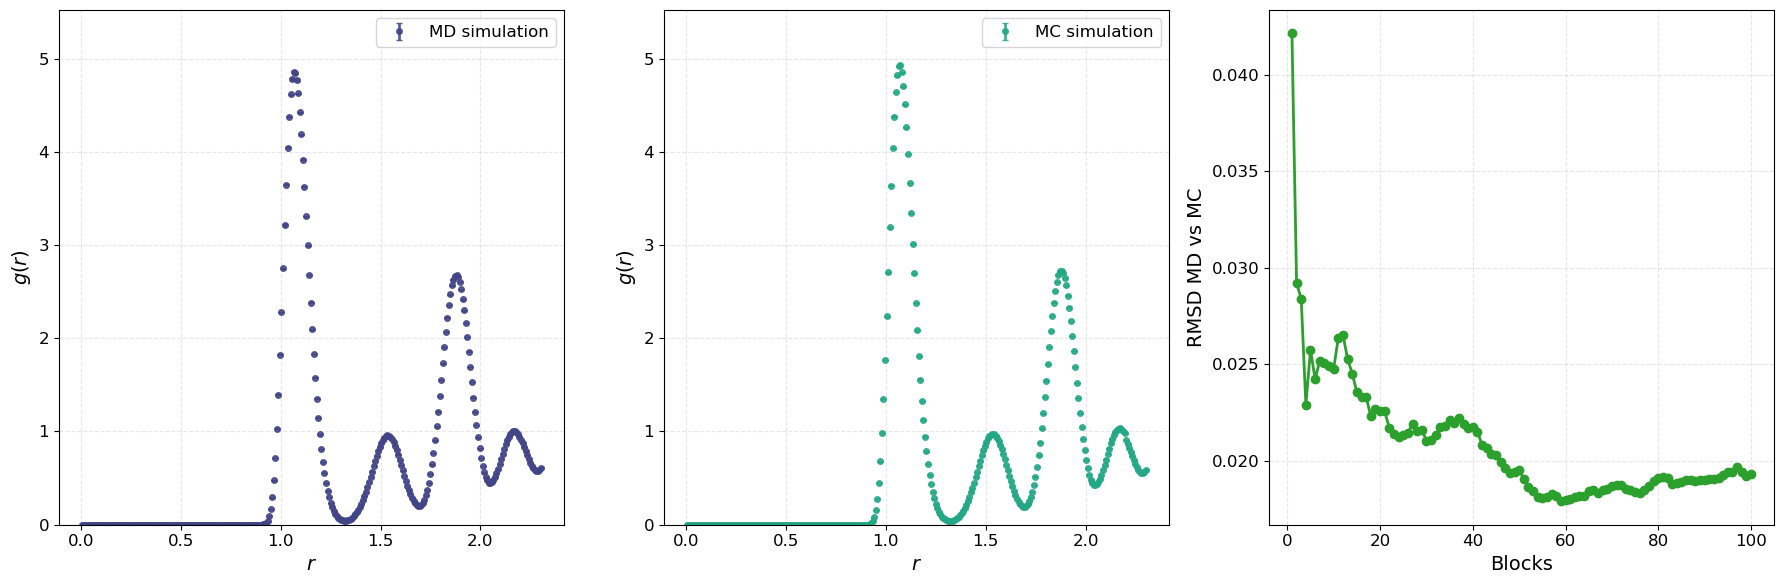

In [86]:
plot_g_r_rmsd(
    "MD_CODE/OUTPUT/SOLID/gofr.dat",
    "MC_CODE/OUTPUT/SOLID/gofr.dat",
    n_bins=300
)

### Liquid phase

Again using _halfside() for the MD code in the thermalization phase

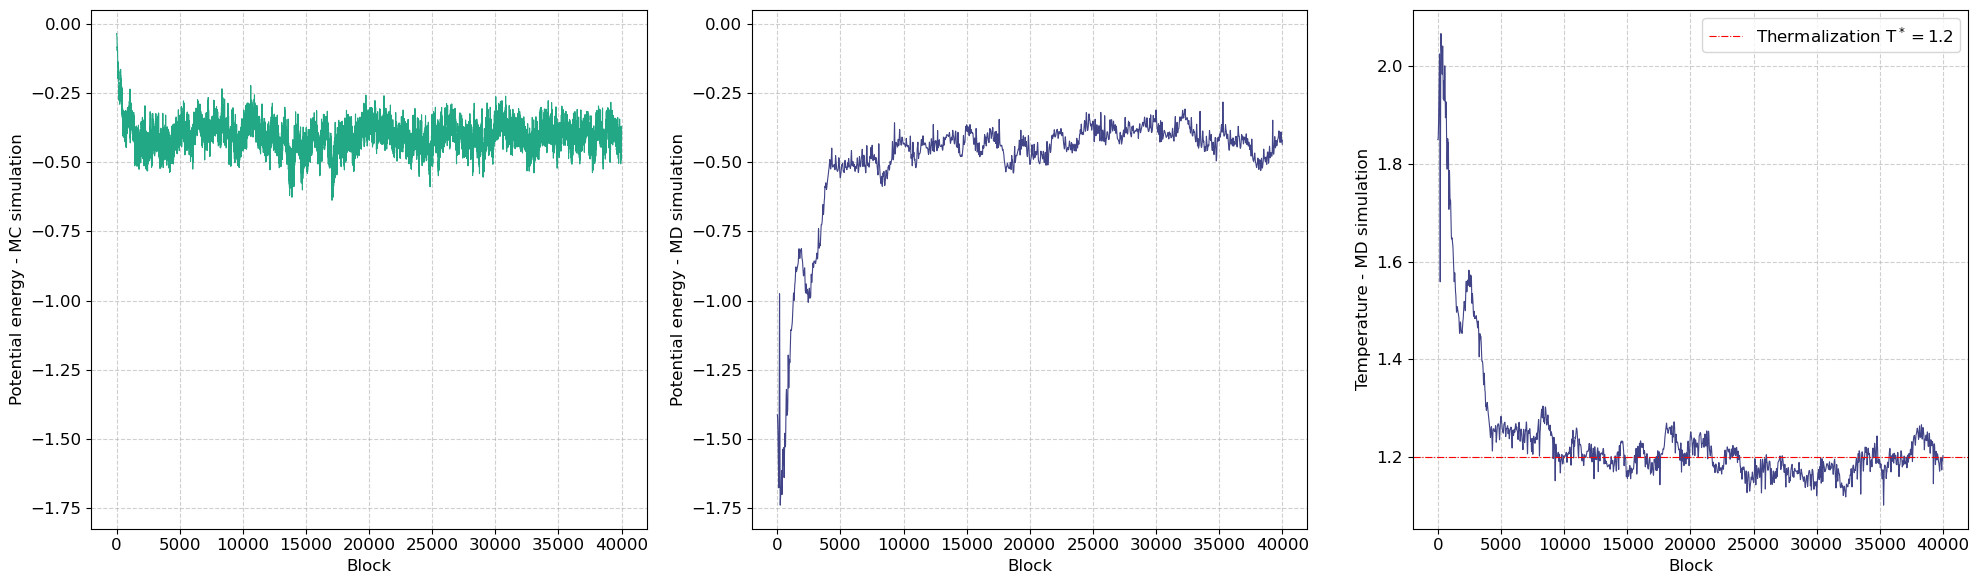

In [87]:
plot_thermalization(
    pot_file_MD='MD_CODE/OUTPUT/GAS/THERMALIZATION/potential_energy.dat',
    pot_file_MC='MC_CODE/OUTPUT/GAS/THERMALIZATION/potential_energy.dat',
    temp_file='MD_CODE/OUTPUT/GAS/THERMALIZATION/temperature.dat',
    T_ref=1.2
)

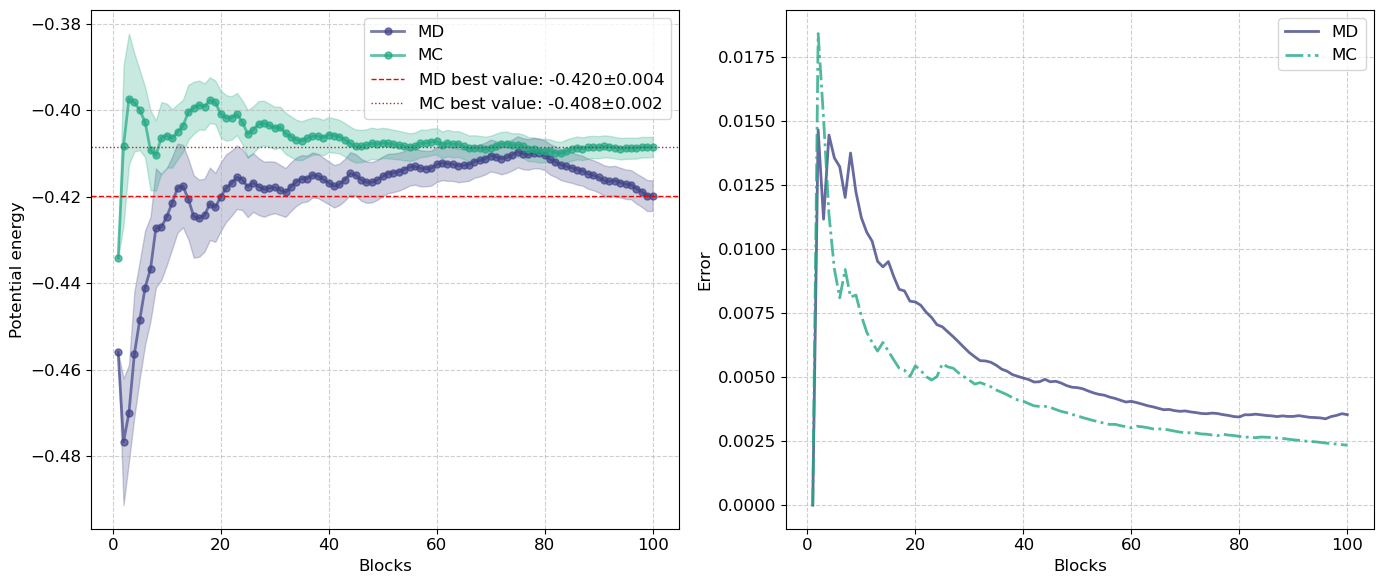

In [88]:
plot_MD_vs_MC("MD_CODE/OUTPUT/GAS/potential_energy.dat", "MC_CODE/OUTPUT/GAS/potential_energy.dat",'Potential energy')

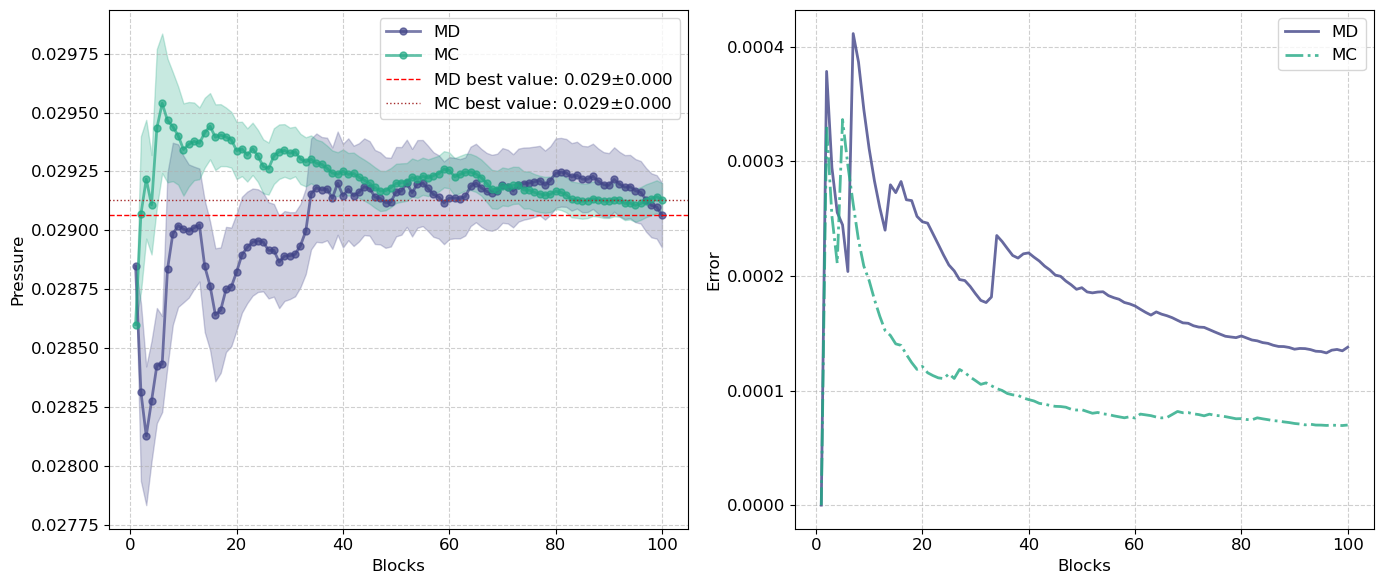

In [89]:
plot_MD_vs_MC("MD_CODE/OUTPUT/GAS/pressure.dat", "MC_CODE/OUTPUT/GAS/pressure.dat",'Pressure')

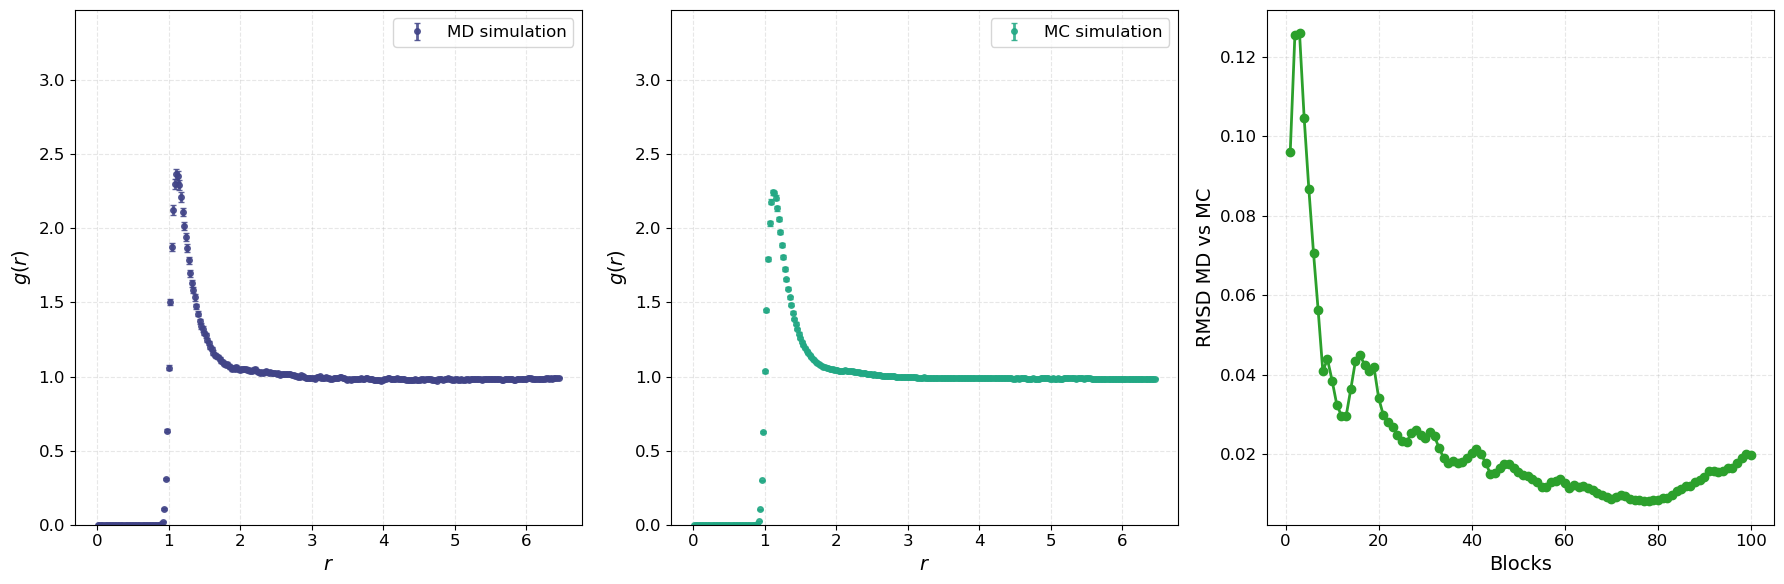

In [90]:
plot_g_r_rmsd(
    "MD_CODE/OUTPUT/GAS/gofr.dat",
    "MC_CODE/OUTPUT/GAS/gofr.dat",
    n_bins=300
)

In [91]:
colors = cm.coolwarm(np.linspace(0,1,4))
colors_multi = {'liquid': colors[0], 'solid': colors[1],'gas': colors[2]}

def plot_phases(liquid_MD, gas_MD, solid_MD,
                 ylabel_energy='Potential energy [eV]',
                 ylabel_error='Statistical error [eV]', choice='MD'):
    files_MD = {'liquid': liquid_MD, 'gas': gas_MD, 'solid': solid_MD}
    fig, axs = plt.subplots(1, 2, figsize=(16, 6), dpi=100, sharex=True)
    for phase in ['liquid', 'gas', 'solid']:
        x_MD, E_MD, err_MD = np.loadtxt(files_MD[phase], usecols=(0,2,3), unpack=True, comments='#')
        axs[0].errorbar(
            x_MD, E_MD, yerr=err_MD,
            fmt='o', capsize=2, elinewidth=1.5,
            color=colors_multi[phase], alpha=0.8, label=f'{choice} {phase}'
        )
        axs[1].plot(
            x_MD, err_MD,
            '-', color=colors_multi[phase], alpha=1, label=f'{choice} {phase}')
    
    axs[0].set_xlabel('Blocks')
    axs[0].set_ylabel(ylabel_energy)
    axs[0].legend()
    axs[0].grid(True, alpha=0.6, linestyle='--')
    
    axs[1].set_xlabel('Blocks')
    axs[1].set_ylabel(ylabel_error)
    axs[1].legend()
    axs[1].grid(True, alpha=0.6, linestyle='--')
    
    plt.tight_layout()
    plt.show()


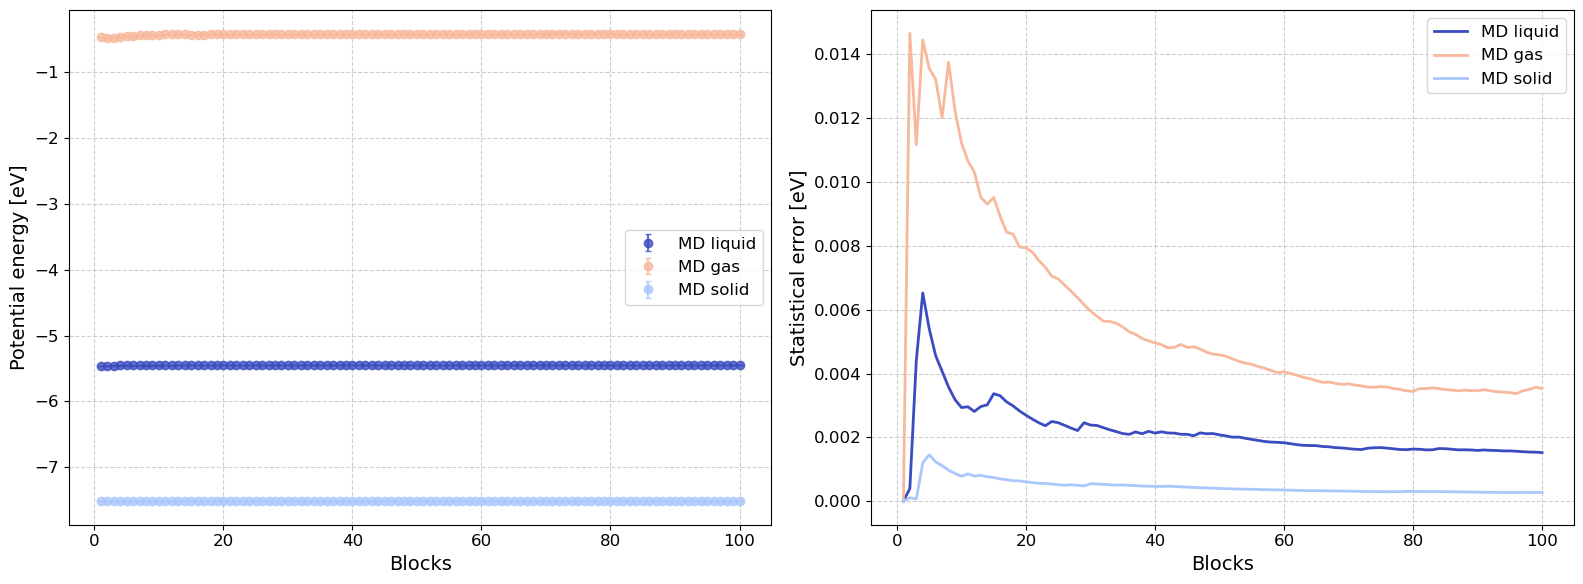

In [92]:
plot_phases(
    "MD_CODE/OUTPUT/FIRST/potential_energy.dat",
    "MD_CODE/OUTPUT/GAS/potential_energy.dat",
    "MD_CODE/OUTPUT/SOLID/potential_energy.dat"
)

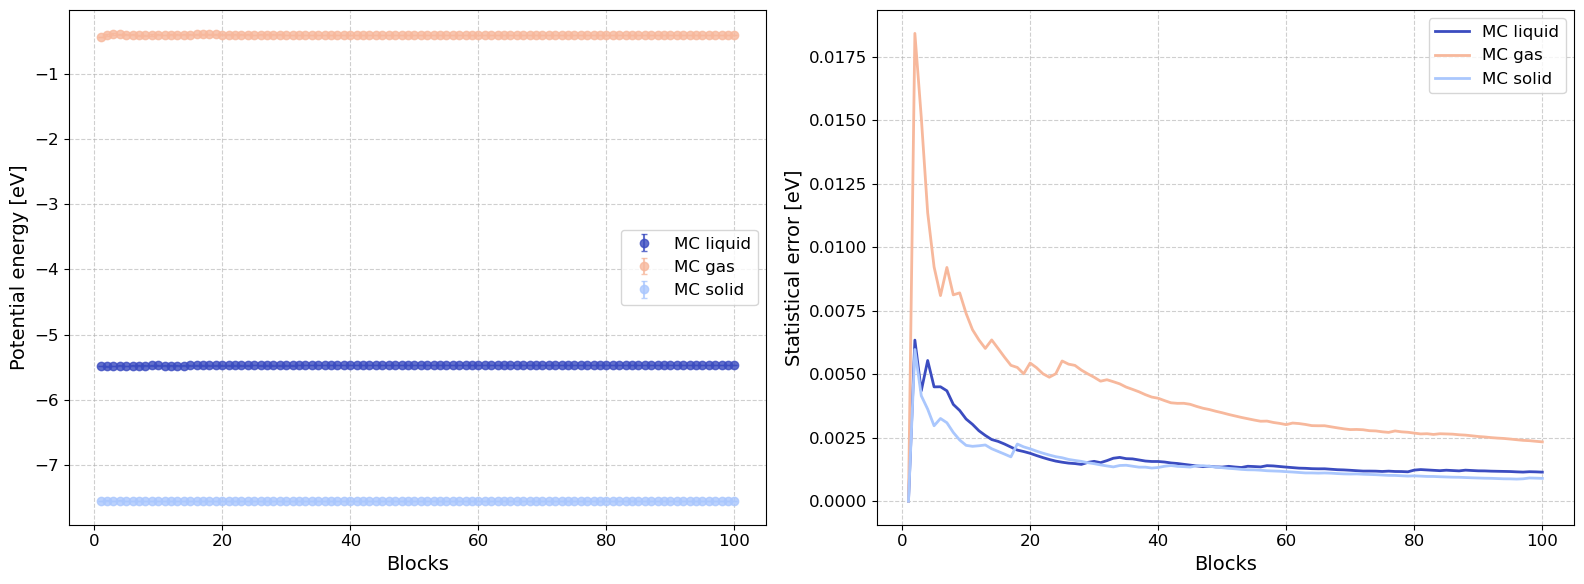

In [93]:
plot_phases(
    "MC_CODE/OUTPUT/FIRST/potential_energy.dat",
    "MC_CODE/OUTPUT/GAS/potential_energy.dat",
    "MC_CODE/OUTPUT/SOLID/potential_energy.dat",
    choice='MC'
)